In [1]:
from datetime import date
from pathlib import Path

from tapas_gmm.dataset.scene import SceneDataset
from tapas_gmm.dataset.bc import BCDataset, BCDataConfig
from torch.utils.data import DataLoader
from tapas_gmm.utils.observation import collate
from tapas_gmm.dataset.demos import Demos

from tapas_gmm.policy.models.tpgmm import (
    AutoTPGMM,
    AutoTPGMMConfig,
    TPGMMConfig,
    FrameSelectionConfig,
    DemoSegmentationConfig,
    FittingStage,
)

2026-07-28 18:15:02.705 | INFO     |  Running on cpu


/home/nils/Documents/Study Project/Code/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
artifact_root = Path("../artifacts")
data_root = artifact_root / "datasets/tapas_diffusion/bimanual_dual_push_buttons"
checkpoint_dir = artifact_root / "checkpoints/tapas" / date.today().isoformat()
checkpoint_dir.mkdir(parents=True, exist_ok=True)

In [3]:
loaded_dataset = SceneDataset(
    data_root=Path(data_root)
)

2026-07-28 18:15:06.745 | INFO     |  Initializing datasete using ../artifacts/datasets/tapas_diffusion/bimanual_dual_push_buttons/metadata.json
2026-07-28 18:15:06.748 | INFO     |  Extracted gt object labels []
2026-07-28 18:15:06.748 | INFO     |  Extracted tsdf object labels []


In [4]:
bc_config = BCDataConfig(
    fragment_length = -1,
    cameras = tuple(),
)

bc_dataset = BCDataset(
    scene_dataset=loaded_dataset,
    config=bc_config,
)

2026-07-28 18:15:08.401 | INFO     |  Initializing BCDataset:
2026-07-28 18:15:08.402 | INFO     |    Training on fragments of length -1.
2026-07-28 18:15:08.402 | INFO     |    Loading raw data for encoder.


In [5]:
loader = DataLoader(
    bc_dataset,
    collate_fn=collate,
)

In [6]:
trajs = []

for traj in loader:
    trajs.append(traj[0])

In [7]:
demos = Demos(trajectories = trajs,
            make_quats_continuous=True,)


2026-07-28 18:15:11.427 | INFO     |  Subsampling to length 101 using strategy mean-length.


In [8]:
tpgmm_config = TPGMMConfig(
    n_components = 10,
    add_time_component = True,
    position_only = False,
    add_action_component = False,
    add_gripper_action=True,

    reg_diag = 2e-4,
    reg_em_finish_diag = 2e-4,
    reg_init_diag = 5e-4,

    reg_em_finish_diag_gripper = 2e-2,
    reg_diag_gripper = 2e-2,
    reg_em_trans = 1e-6,
)

segmentation_config = DemoSegmentationConfig(
    distance_based = False,
    velocity_based = True,
    components_prop_to_len = True,
    min_n_components = 3,
)

frame_selection_config = FrameSelectionConfig(
    rel_score_threshold = 0.1,
)

auto_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=segmentation_config,
)


In [9]:
model = AutoTPGMM(auto_config)

2026-07-28 18:15:13.409 | INFO     |  Fitting AutoTPGMM
2026-07-28 18:15:13.409 | INFO     |  Performing fitting actions: [INIT, EM_HMM]
2026-07-28 18:15:13.410 | INFO     |  Segmenting trajectories


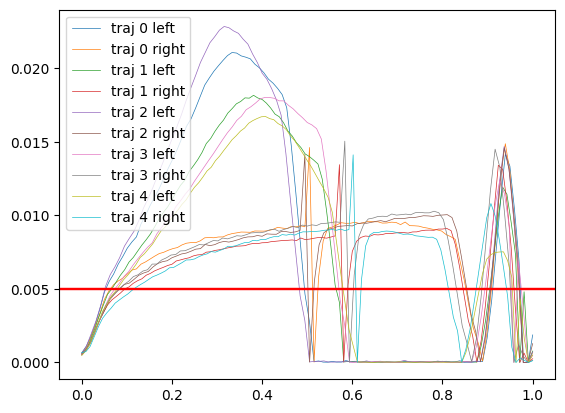

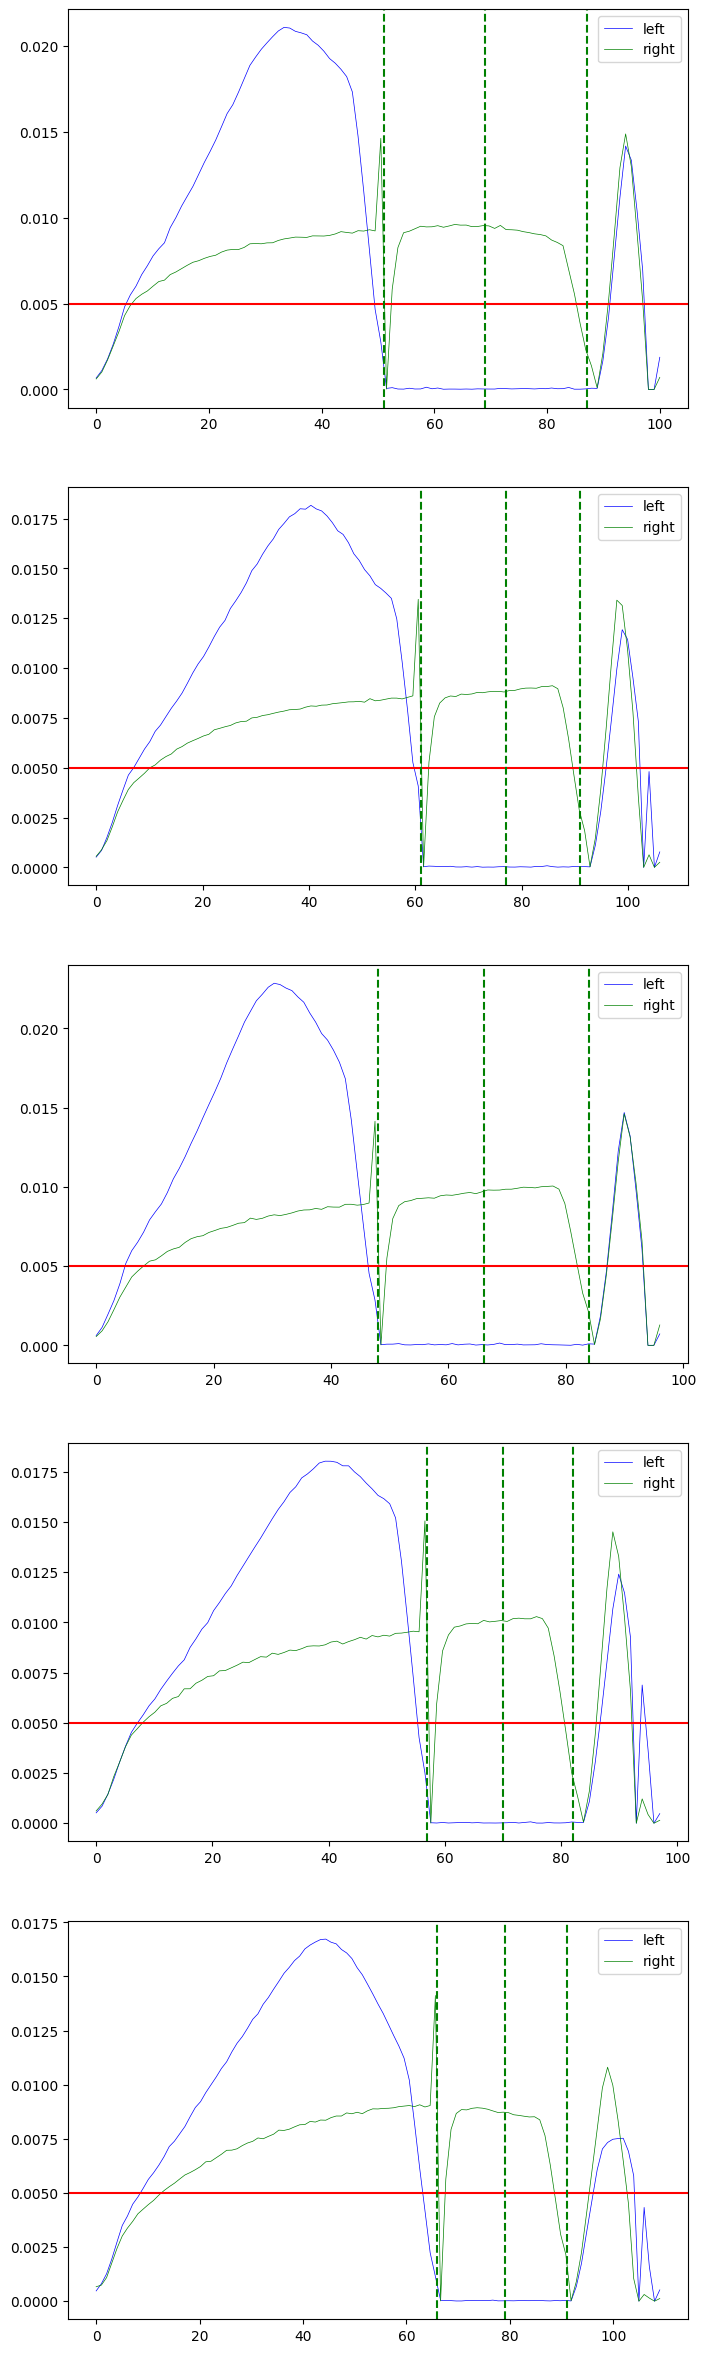

2026-07-28 18:15:14.229 | INFO     |  Creating segement of demos.
2026-07-28 18:15:14.239 | INFO     |  Subsampling to length 65 using strategy mean-length.
2026-07-28 18:15:14.241 | INFO     |  Creating segement of demos.
2026-07-28 18:15:14.254 | INFO     |  Subsampling to length 24 using strategy mean-length.
2026-07-28 18:15:14.257 | INFO     |  Creating segement of demos.
2026-07-28 18:15:14.273 | INFO     |  Subsampling to length 23 using strategy mean-length.
2026-07-28 18:15:14.274 | INFO     |  Creating segement of demos.
2026-07-28 18:15:14.284 | INFO     |  ... created 4 segments
2026-07-28 18:15:14.284 | INFO     |    Fitting candidate frame 1/5
2026-07-28 18:15:14.284 | INFO     |    Creating partial frame view of demos.
2026-07-28 18:15:14.290 | INFO     |    Manifold: TIME x R3 x QUAT x R1 x R1
2026-07-28 18:15:14.290 | INFO     |    Changing number of components to 4
2026-07-28 18:15:14.291 | INFO     |    Init strategy not specified. Auto selected InitStrategy.TIME_BAS

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2026-07-28 18:15:14.507 | INFO     |    HMM EM ...
2026-07-28 18:15:14.509 | INFO     |    HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-28 18:15:14.539 | INFO     |    HMM init priors not defined, initializing to uniform
2026-07-28 18:15:15.518 | INFO     |    HMM EM converged
2026-07-28 18:15:15.566 | INFO     |    Creating partial frame view of demos.


...

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

2026-07-28 18:16:42.079 | WARNING  |  Gaussian mle not converged in 50 iterations.


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
lik, avg_loglik = model.fit_trajectories(
    demos = demos,
    fix_frames=True,
    fitting_actions = [ 
        FittingStage.INIT,
        FittingStage.EM_HMM,
    ],
)

2026-07-28 18:16:43.829 | INFO     |  Did not specify time_based, deciding automatically.


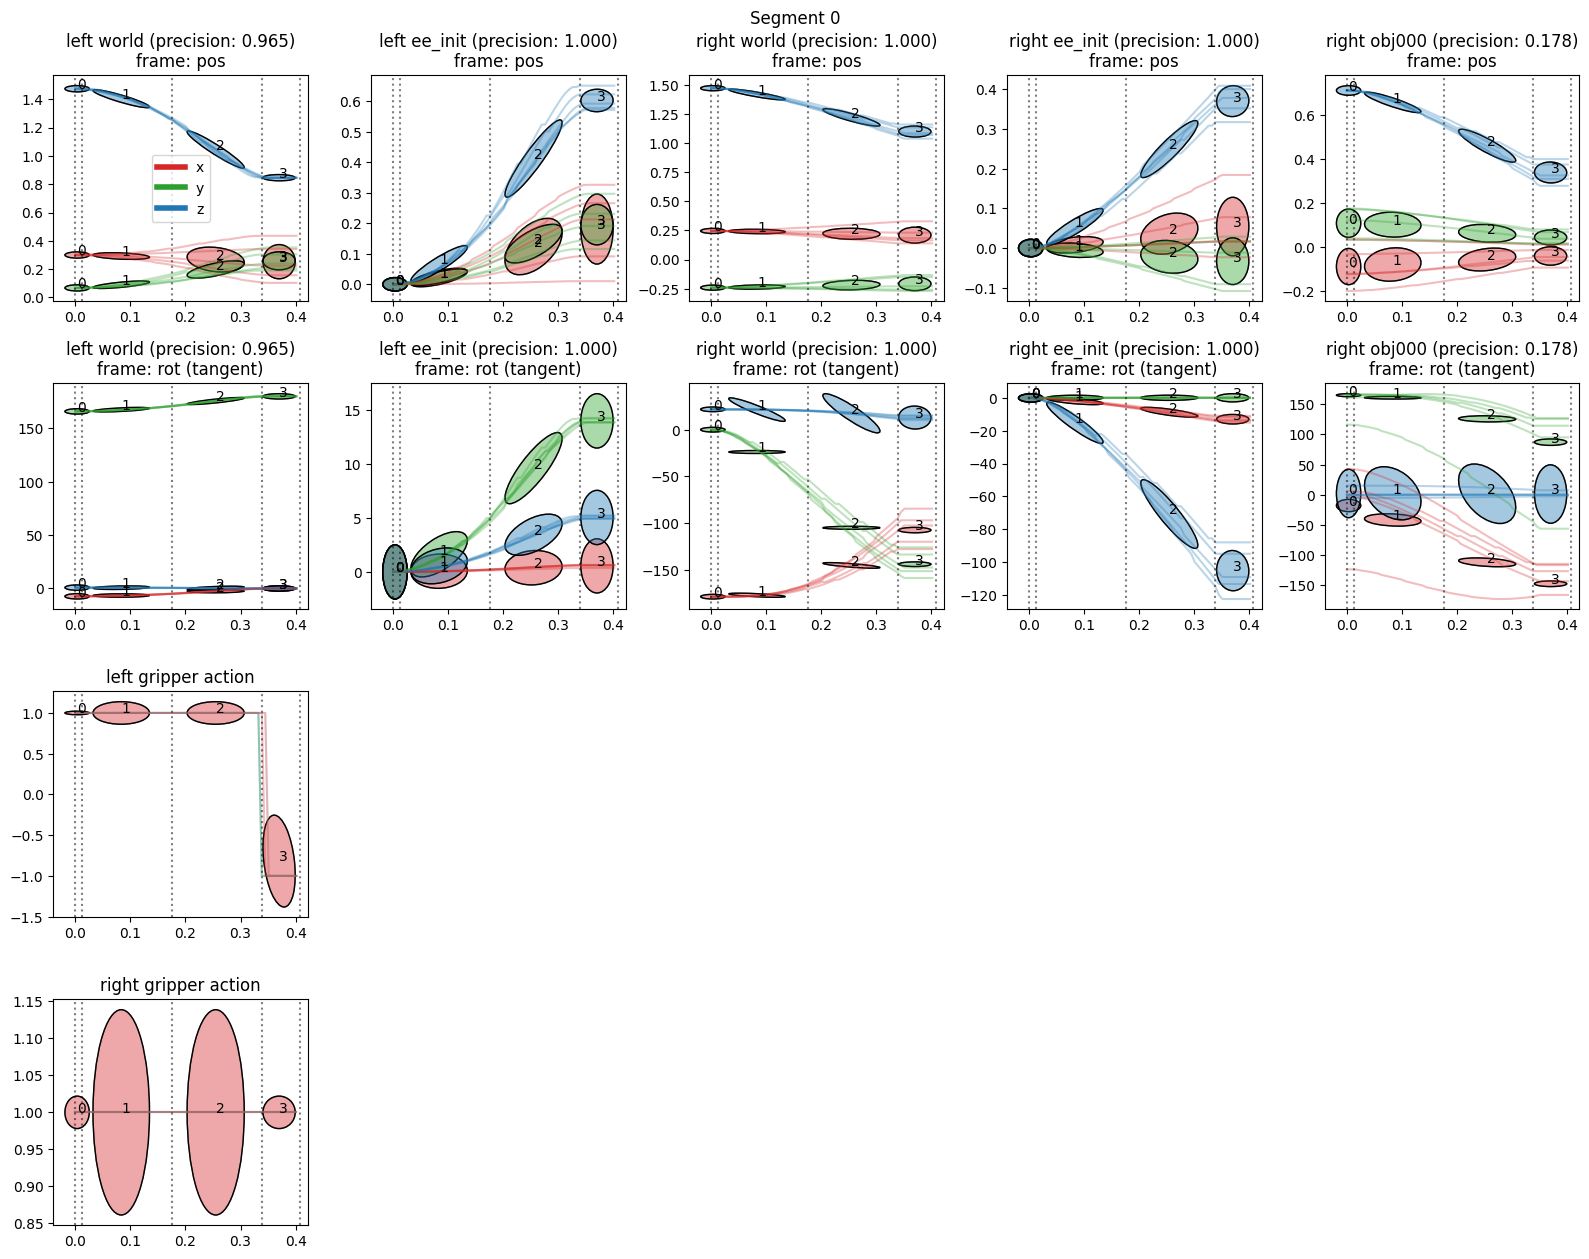

2026-07-28 18:16:47.047 | INFO     |  Did not specify time_based, deciding automatically.


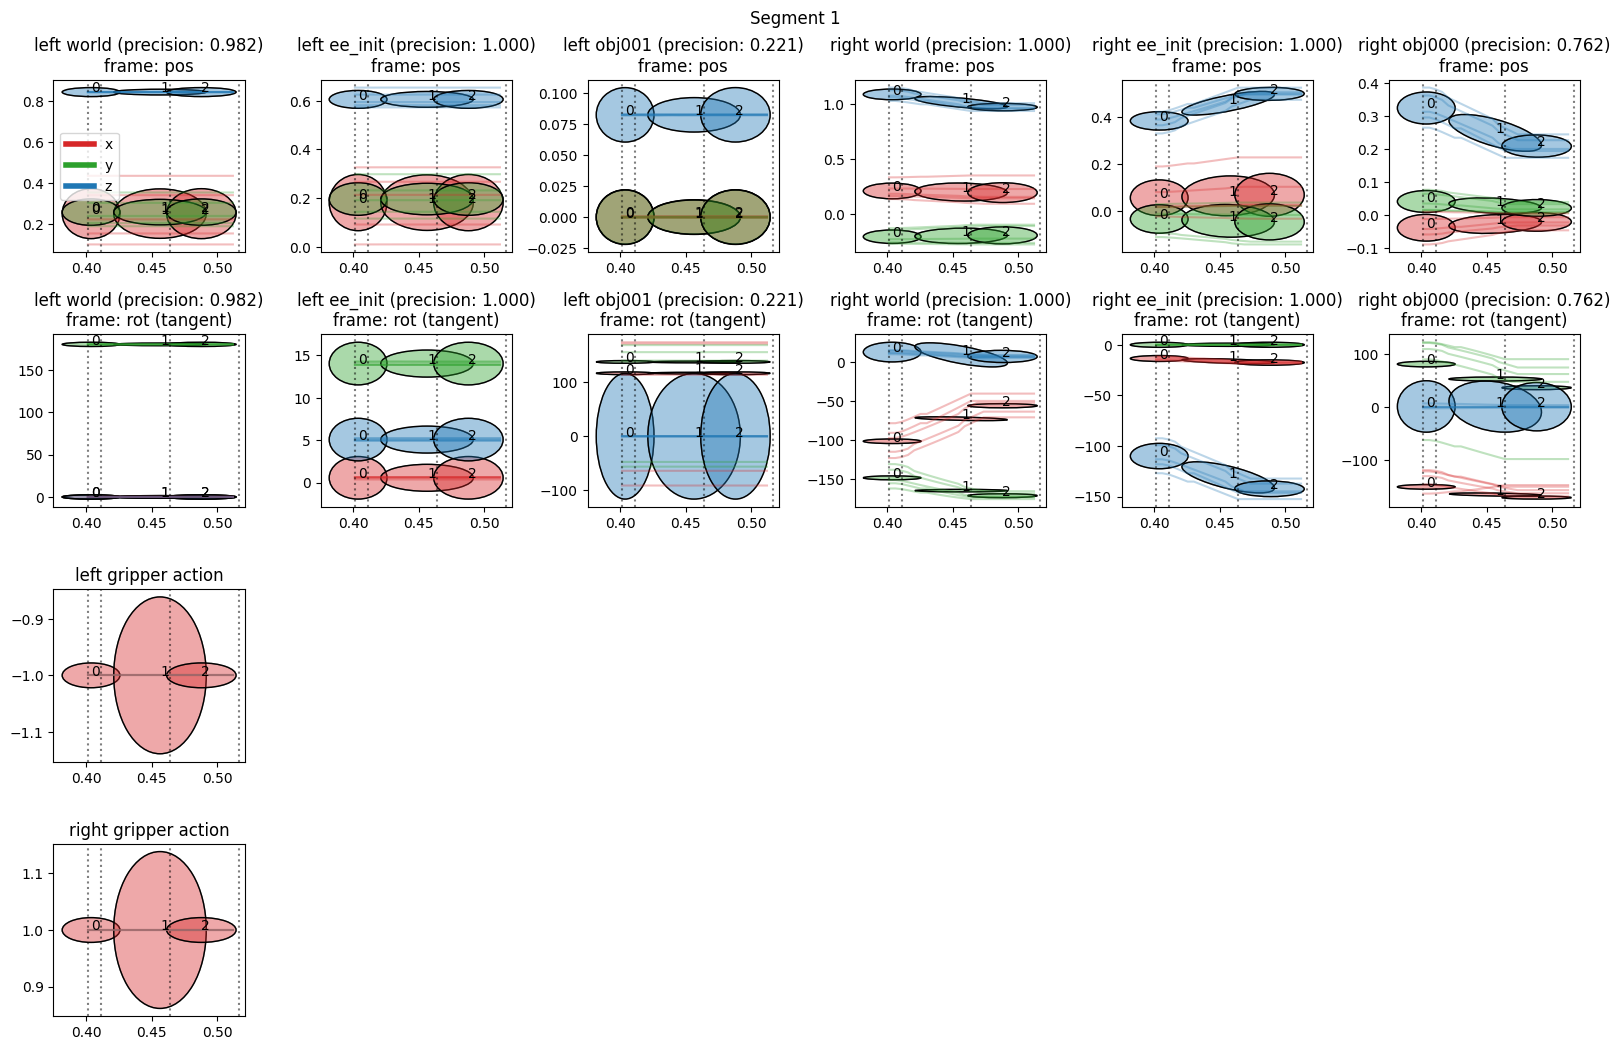

2026-07-28 18:16:50.054 | INFO     |  Did not specify time_based, deciding automatically.


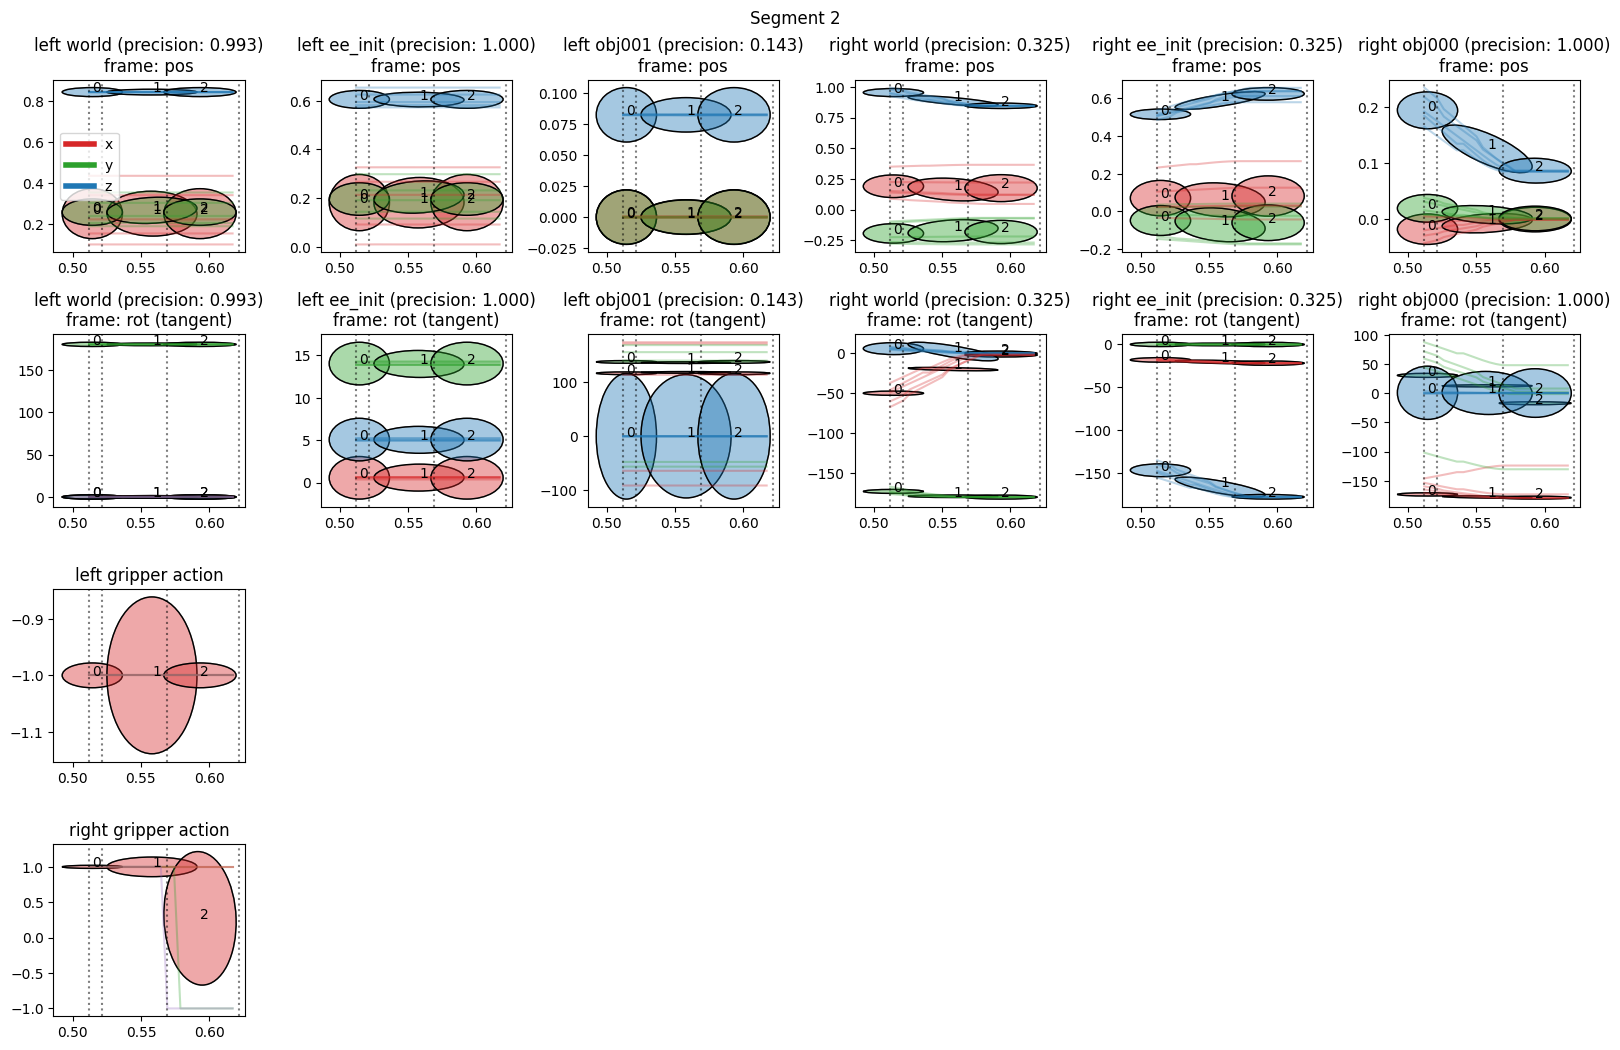

2026-07-28 18:16:53.687 | INFO     |  Did not specify time_based, deciding automatically.


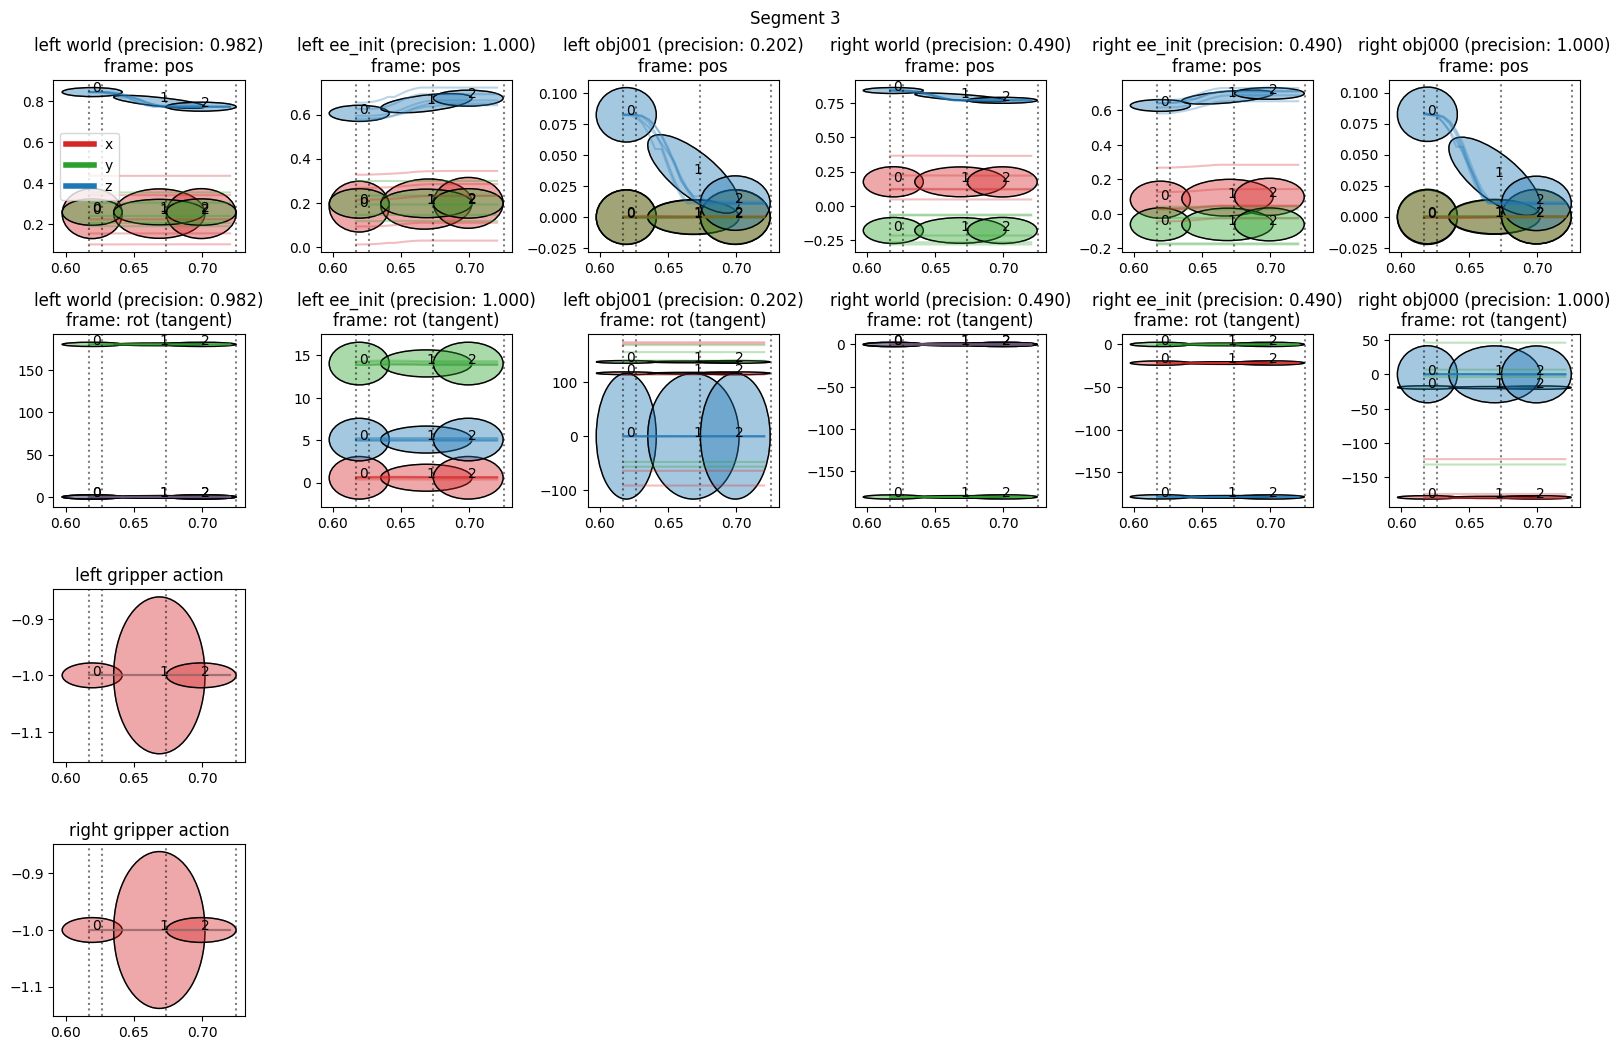

In [11]:
model.plot_model(
    rotations_raw=False,
    per_segment=True,
    mean_as_base=False,
)

In [12]:
model.to_disk(str(checkpoint_dir / "latest.pkl"))

2026-07-28 18:16:56.936 | INFO     |  Saving model:
